# 06. Klaidų analizė švariame TEST rinkinyje

Šiame etape **nedarome** naujo skaidymo, GridSearch, abliacijos, triukšmo ir SOM. Tikslas — švariame TEST parodyti ne tik bendras metrikas, bet ir:

- kokias veiklas modeliai painioja;
- kiek klaidų tenka kiekvienai klasei;
- konkrečius klaidingus TEST įrašus;
- ar klaidos telkiasi ties klasėmis ar nematytų TEST subject.

Hiperparametrai fiksuoti: k-NN `n_neighbors=11`, `weights=distance`; SVM `C=0.01`; MLP `hidden_layer_sizes=(100,)`, `alpha=0.001`, `random_state=42`, `max_iter=500`.

**Apribojimas.** Vienas UCI HAR TEST įrašas yra apdorotas signalo langas (561 požymių vektorius), o ne originalus telefono IMU grafikas ar nuotrauka. Galime parodyti TEST eilutę, subject, tikrą ir prognozuotą klasę. Iš 561 požymių **negalime** vienareikšmiškai rekonstruoti žalio IMU lango.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"RANDOM_STATE = {RANDOM_STATE}")

RANDOM_STATE = 42


## Duomenys

Naudojamas tik `results/subject_disjoint_split.npz`. Naujo TRAIN/TEST nekuriame. Scaler `fit` tik TRAIN.

In [2]:
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
project_root = None
for cand in candidates:
    if (cand / "results").exists() and (cand / "notebooks").exists():
        project_root = cand
        break
if project_root is None:
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

results_dir = project_root / "results"
split = np.load(results_dir / "subject_disjoint_split.npz", allow_pickle=True)
X_train = split["X_train_final"]
X_test = split["X_test_final"]
y_train = split["y_train_final"]
y_test = split["y_test_final"]
subjects_train = split["subjects_train_final"]
subjects_test = split["subjects_test_final"]
activity_ids = [int(i) for i in split["activity_ids"]]
activity_names = [str(n) for n in split["activity_names"]]
id_to_name = dict(zip(activity_ids, activity_names))
class_names = [id_to_name[i] for i in activity_ids]
overlap = sorted(set(subjects_train.tolist()) & set(subjects_test.tolist()))

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Klasės:", class_names)
print("TRAIN ∩ TEST subject:", overlap)
assert X_train.shape == (7144, 561)
assert X_test.shape == (3155, 561)
assert overlap == []
print("Patikra OK.")

X_train: (7144, 561) X_test: (3155, 561)
Klasės: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
TRAIN ∩ TEST subject: []
Patikra OK.


## Modeliai ir kontrolinė patikra

`Pipeline`: `StandardScaler` + klasifikatorius. `fit` tik švariam TRAIN, `predict` tik švariam TEST. Be GridSearch.

In [3]:
caught_warnings = []
pipelines = {
    "k-NN": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=11, weights="distance")),
        ]
    ),
    "SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LinearSVC(
                    C=0.01,
                    random_state=RANDOM_STATE,
                    max_iter=10000,
                    dual="auto",
                ),
            ),
        ]
    ),
    "MLP": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                MLPClassifier(
                    hidden_layer_sizes=(100,),
                    alpha=0.001,
                    random_state=RANDOM_STATE,
                    max_iter=500,
                ),
            ),
        ]
    ),
}

preds = {}
for name, pipe in pipelines.items():
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        pipe.fit(X_train, y_train)
        unique = []
        for item in caught:
            msg = f"{item.category.__name__}: {item.message}"
            caught_warnings.append({"etapas": name, "pranesimas": msg})
            if msg not in unique:
                unique.append(msg)
                print(f"[{name}] {msg}")
        if not unique:
            print(f"[{name}] Warning nebuvo.")
    preds[name] = pipe.predict(X_test)

prev = pd.concat(
    [
        pd.read_csv(results_dir / "baseline_results.csv"),
        pd.read_csv(results_dir / "intelligent_models_results.csv"),
    ],
    ignore_index=True,
)
prev = prev[prev["Model"].isin(["k-NN", "SVM", "MLP"])].set_index("Model")

print()
for name, y_pred in preds.items():
    f1 = f1_score(y_test, y_pred, average="macro")
    ba = balanced_accuracy_score(y_test, y_pred)
    n_err = int(np.sum(y_pred != y_test))
    f1_ok = np.isclose(f1, prev.loc[name, "Macro-F1"], rtol=0.0, atol=1e-12)
    ba_ok = np.isclose(ba, prev.loc[name, "Balanced Accuracy"], rtol=0.0, atol=1e-12)
    status = "SUTAMPA" if (f1_ok and ba_ok) else "NESUTAMPA"
    print(
        f"{name}: Macro-F1={f1:.6f}, BA={ba:.6f}, klaidos={n_err}/{len(y_test)} -> {status}"
    )

[k-NN] Warning nebuvo.
[SVM] Warning nebuvo.
[MLP] Warning nebuvo.

k-NN: Macro-F1=0.844324, BA=0.842074, klaidos=491/3155 -> SUTAMPA
SVM: Macro-F1=0.897130, BA=0.893666, klaidos=347/3155 -> SUTAMPA
MLP: Macro-F1=0.896616, BA=0.894957, klaidos=340/3155 -> SUTAMPA


## Confusion matrix

Absoliutūs skaičiai ir eilutėmis normuota matrica (kiekvienos tikros klasės klaidų dalis). SVG skirti ataskaitai.


k-NN confusion matrix (skaičiai):
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
WALKING                 483                23                   2        0         0       0
WALKING_UPSTAIRS         33               450                   1        0         0       0
WALKING_DOWNSTAIRS       48                86                 302        0         0       0
SITTING                   0                 1                   0      425       118       0
STANDING                  0                 0                   0       74       510       0
LAYING                    0                 0                   0       39        66     494

k-NN row-normalized:
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
WALKING               0.951             0.045               0.004    0.000     0.000   0.000
WALKING_UPSTAIRS      0.068             0.930               0.002    0.000     0.000   0.000
WALKING_DOWNS

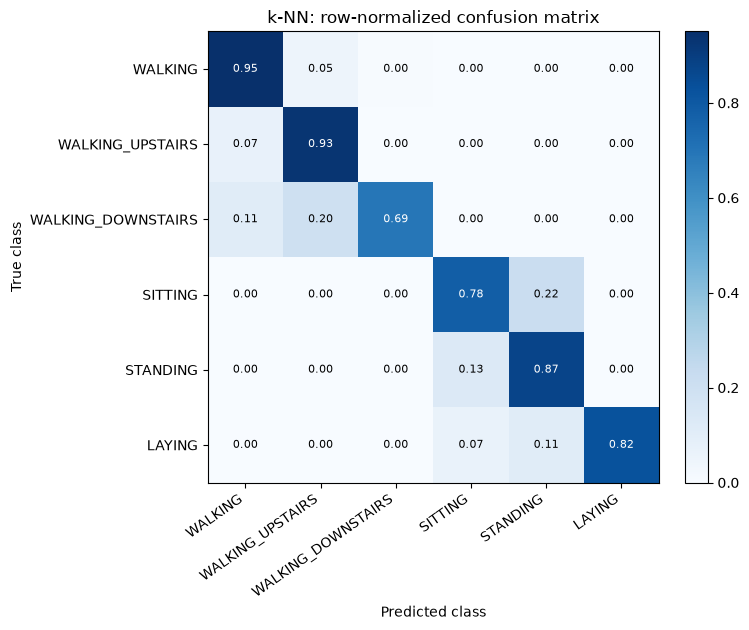


SVM confusion matrix (skaičiai):
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
WALKING                 505                 2                   0        1         0       0
WALKING_UPSTAIRS         10               414                   1       59         0       0
WALKING_DOWNSTAIRS        3                18                 414        1         0       0
SITTING                   0                 2                   0      472        70       0
STANDING                  0                 0                   0       97       487       0
LAYING                    0                 0                   0        0        83     516

SVM row-normalized:
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
WALKING               0.994             0.004               0.000    0.002     0.000   0.000
WALKING_UPSTAIRS      0.021             0.855               0.002    0.122     0.000   0.000
WALKING_DOWNSTA

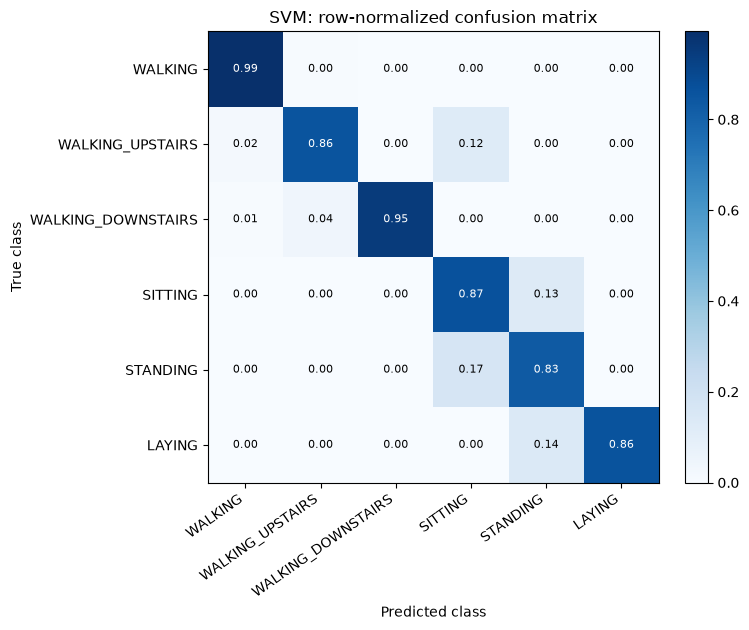


MLP confusion matrix (skaičiai):
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
WALKING                 504                 2                   2        0         0       0
WALKING_UPSTAIRS         20               461                   2        1         0       0
WALKING_DOWNSTAIRS       12                43                 380        0         1       0
SITTING                   0                 1                   0      468        74       1
STANDING                  0                 0                   0      106       478       0
LAYING                    0                 1                   0        4        70     524

MLP row-normalized:
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
WALKING               0.992             0.004               0.004    0.000     0.000   0.000
WALKING_UPSTAIRS      0.041             0.952               0.004    0.002     0.000   0.000
WALKING_DOWNSTA

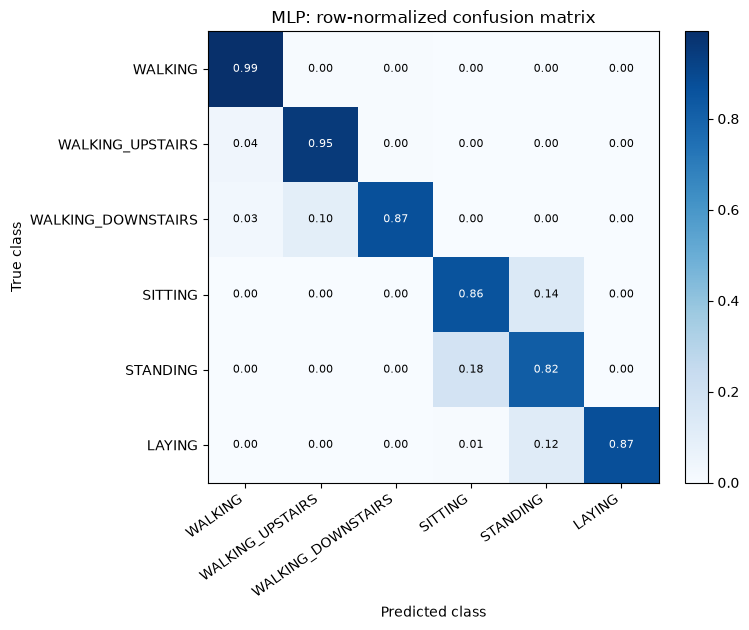

In [4]:
cms = {}
cms_norm = {}


def save_heatmap(cm, title, path_stem, fmt):
    fig, ax = plt.subplots(figsize=(8.2, 6.4))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(class_names)), class_names, rotation=35, ha="right")
    ax.set_yticks(range(len(class_names)), class_names)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    vmax = np.nanmax(cm) if np.nanmax(cm) > 0 else 1.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            text = f"{val:.0f}" if fmt == "d" else f"{val:.2f}"
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                color="white" if val > 0.55 * vmax else "black",
                fontsize=8,
            )
    fig.tight_layout()
    fig.savefig(results_dir / f"{path_stem}.svg", format="svg")
    fig.savefig(results_dir / f"{path_stem}.png", format="png", dpi=200)
    plt.show()
    plt.close(fig)


file_stems = {"k-NN": "knn", "SVM": "svm", "MLP": "mlp"}
for name, y_pred in preds.items():
    cm = confusion_matrix(y_test, y_pred, labels=activity_ids)
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sum, out=np.zeros_like(cm, dtype=float), where=row_sum != 0)
    cms[name] = cm
    cms_norm[name] = cm_norm
    print(f"\n{name} confusion matrix (skaičiai):")
    print(pd.DataFrame(cm, index=class_names, columns=class_names).to_string())
    print(f"\n{name} row-normalized:")
    print(pd.DataFrame(cm_norm, index=class_names, columns=class_names).round(3).to_string())
    save_heatmap(
        cm_norm,
        f"{name}: row-normalized confusion matrix",
        f"{file_stems[name]}_confusion_matrix_normalized",
        fmt="f",
    )

## Per-class metrikos

Precision, recall, F1 ir support kiekvienai veiklai. `zero_division=0`.

In [5]:
per_class_rows = []
for name, y_pred in preds.items():
    rep = classification_report(
        y_test,
        y_pred,
        labels=activity_ids,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    print(f"\n{name}")
    print(
        classification_report(
            y_test,
            y_pred,
            labels=activity_ids,
            target_names=class_names,
            zero_division=0,
            digits=4,
        )
    )
    for cls in class_names:
        per_class_rows.append(
            {
                "Model": name,
                "Class": cls,
                "Precision": float(rep[cls]["precision"]),
                "Recall": float(rep[cls]["recall"]),
                "F1-score": float(rep[cls]["f1-score"]),
                "Support": int(rep[cls]["support"]),
            }
        )

per_class = pd.DataFrame(per_class_rows)
print(per_class.to_string(index=False))


k-NN
                    precision    recall  f1-score   support

           WALKING     0.8564    0.9508    0.9011       508
  WALKING_UPSTAIRS     0.8036    0.9298    0.8621       484
WALKING_DOWNSTAIRS     0.9902    0.6927    0.8151       436
           SITTING     0.7900    0.7812    0.7856       544
          STANDING     0.7349    0.8733    0.7981       584
            LAYING     1.0000    0.8247    0.9039       599

          accuracy                         0.8444      3155
         macro avg     0.8625    0.8421    0.8443      3155
      weighted avg     0.8601    0.8444    0.8448      3155


SVM
                    precision    recall  f1-score   support

           WALKING     0.9749    0.9941    0.9844       508
  WALKING_UPSTAIRS     0.9495    0.8554    0.9000       484
WALKING_DOWNSTAIRS     0.9976    0.9495    0.9730       436
           SITTING     0.7492    0.8676    0.8041       544
          STANDING     0.7609    0.8339    0.7958       584
            LAYING     1.

## Dažniausios klaidų poros

Tik nediagonaliniai confusion langeliai. TOP 5 pagal skaičių kiekvienam modeliui. Porų iš anksto neįtariame.

In [6]:
pair_rows = []
for name, cm in cms.items():
    items = []
    for i, true_cls in enumerate(class_names):
        true_n = cm[i].sum()
        for j, pred_cls in enumerate(class_names):
            if i == j:
                continue
            cnt = int(cm[i, j])
            if cnt == 0:
                continue
            pct = (cnt / true_n) if true_n else 0.0
            items.append((cnt, true_cls, pred_cls, pct))
    items.sort(key=lambda t: (-t[0], t[1], t[2]))
    print(f"\n{name} TOP 5 klaidų poros:")
    for cnt, true_cls, pred_cls, pct in items[:5]:
        pair_rows.append(
            {
                "Model": name,
                "True Class": true_cls,
                "Predicted Class": pred_cls,
                "Count": cnt,
                "Percent of True Class": pct,
            }
        )
        print(f"  {true_cls} -> {pred_cls}: {cnt} ({pct:.1%} true class)")

top_pairs = pd.DataFrame(pair_rows)
print()
print(top_pairs.to_string(index=False))


k-NN TOP 5 klaidų poros:
  SITTING -> STANDING: 118 (21.7% true class)
  WALKING_DOWNSTAIRS -> WALKING_UPSTAIRS: 86 (19.7% true class)
  STANDING -> SITTING: 74 (12.7% true class)
  LAYING -> STANDING: 66 (11.0% true class)
  WALKING_DOWNSTAIRS -> WALKING: 48 (11.0% true class)

SVM TOP 5 klaidų poros:
  STANDING -> SITTING: 97 (16.6% true class)
  LAYING -> STANDING: 83 (13.9% true class)
  SITTING -> STANDING: 70 (12.9% true class)
  WALKING_UPSTAIRS -> SITTING: 59 (12.2% true class)
  WALKING_DOWNSTAIRS -> WALKING_UPSTAIRS: 18 (4.1% true class)

MLP TOP 5 klaidų poros:
  STANDING -> SITTING: 106 (18.2% true class)
  SITTING -> STANDING: 74 (13.6% true class)
  LAYING -> STANDING: 70 (11.7% true class)
  WALKING_DOWNSTAIRS -> WALKING_UPSTAIRS: 43 (9.9% true class)
  WALKING_UPSTAIRS -> WALKING: 20 (4.1% true class)

Model         True Class  Predicted Class  Count  Percent of True Class
 k-NN            SITTING         STANDING    118               0.216912
 k-NN WALKING_DOWNSTAIRS 

## Konkretūs klaidingi TEST pavyzdžiai

Kiekvienam modeliui bent 10 realių klaidų (pirmos pagal TEST eilės indeksą). CSV saugo **visas** klaidas. SVM eilutėse papildomai: tikros ir prognozuotos klasės `decision_function` balai.

In [7]:
svm_scores = pipelines["SVM"].decision_function(X_test)
svm_classes = pipelines["SVM"].named_steps["clf"].classes_
cls_to_col = {int(c): i for i, c in enumerate(svm_classes)}

misc_rows = []
for name, y_pred in preds.items():
    bad = np.where(y_pred != y_test)[0]
    print(f"\n{name}: klaidų {len(bad)}. Pirmi 10:")
    for idx in bad:
        true_id = int(y_test[idx])
        pred_id = int(y_pred[idx])
        row = {
            "Model": name,
            "Test Row Index": int(idx),
            "Subject ID": int(subjects_test[idx]),
            "True Class": id_to_name[true_id],
            "Predicted Class": id_to_name[pred_id],
            "SVM score true": np.nan,
            "SVM score predicted": np.nan,
        }
        if name == "SVM":
            row["SVM score true"] = float(svm_scores[idx, cls_to_col[true_id]])
            row["SVM score predicted"] = float(svm_scores[idx, cls_to_col[pred_id]])
        misc_rows.append(row)
    show = pd.DataFrame(misc_rows[-len(bad):]).head(10)
    cols = ["Test Row Index", "Subject ID", "True Class", "Predicted Class"]
    if name == "SVM":
        cols += ["SVM score true", "SVM score predicted"]
    print(show[cols].to_string(index=False))

misclassified = pd.DataFrame(misc_rows)
print("\nIš viso klaidų eilučių CSV:", len(misclassified))


k-NN: klaidų 491. Pirmi 10:
 Test Row Index  Subject ID True Class Predicted Class
              6          16   STANDING         SITTING
             10          16   STANDING         SITTING
             12          16   STANDING         SITTING
             37          16    SITTING        STANDING
             38          16    SITTING        STANDING
             39          16    SITTING        STANDING
             41          16    SITTING        STANDING
             42          16    SITTING        STANDING
             45          16    SITTING        STANDING
             48          16    SITTING        STANDING

SVM: klaidų 347. Pirmi 10:
 Test Row Index  Subject ID True Class Predicted Class  SVM score true  SVM score predicted
              0          16   STANDING         SITTING       -0.302043             0.055874
              6          16   STANDING         SITTING       -0.624554             0.617996
             36          16    SITTING        STANDING       -

## Klaidos pagal TEST subject

Projekto tikslas — generalizacija į nematytą žmogų. Subject lygio Macro-F1 skaičiuojamas **tik pagal tame subject esančias tikras klases** (`labels=unique(y_true)`), `zero_division=0`. Jei subject neturi visų 6 klasių, tai pažymima stulpelyje `N True Classes`. Tai ne žmonių reitingas — tik ar rezultatai tarp nematytų subject skiriasi.

In [8]:
subj_rows = []
test_subjects = sorted(np.unique(subjects_test).tolist())
for name, y_pred in preds.items():
    for sid in test_subjects:
        mask = subjects_test == sid
        y_s = y_test[mask]
        p_s = y_pred[mask]
        present = np.unique(y_s)
        subj_rows.append(
            {
                "Model": name,
                "Subject ID": int(sid),
                "N Samples": int(mask.sum()),
                "N True Classes": int(len(present)),
                "Accuracy": float(accuracy_score(y_s, p_s)),
                "Macro-F1": float(
                    f1_score(
                        y_s,
                        p_s,
                        average="macro",
                        labels=present,
                        zero_division=0,
                    )
                ),
            }
        )

per_subject = pd.DataFrame(subj_rows)
print(per_subject.to_string(index=False))
print()
print("N True Classes pasiskirstymas:")
print(per_subject["N True Classes"].value_counts().to_string())
print()
for name in ["k-NN", "SVM", "MLP"]:
    sub = per_subject[per_subject["Model"] == name]
    print(
        f"{name} Macro-F1 pagal subject: min={sub['Macro-F1'].min():.4f}, "
        f"max={sub['Macro-F1'].max():.4f}, mean={sub['Macro-F1'].mean():.4f}"
    )

Model  Subject ID  N Samples  N True Classes  Accuracy  Macro-F1
 k-NN           9        288               6  0.847222  0.846363
 k-NN          10        294               6  0.727891  0.735641
 k-NN          13        327               6  0.905199  0.896120
 k-NN          16        366               6  0.816940  0.832021
 k-NN          18        364               6  0.818681  0.761179
 k-NN          24        381               6  0.944882  0.943614
 k-NN          25        409               6  0.782396  0.726226
 k-NN          28        382               6  0.793194  0.820176
 k-NN          29        344               6  0.959302  0.961274
  SVM           9        288               6  0.770833  0.777752
  SVM          10        294               6  0.700680  0.715549
  SVM          13        327               6  0.990826  0.990232
  SVM          16        366               6  0.710383  0.751001
  SVM          18        364               6  0.980769  0.979188
  SVM          24        

## Grafikas: Macro-F1 pagal TEST subject

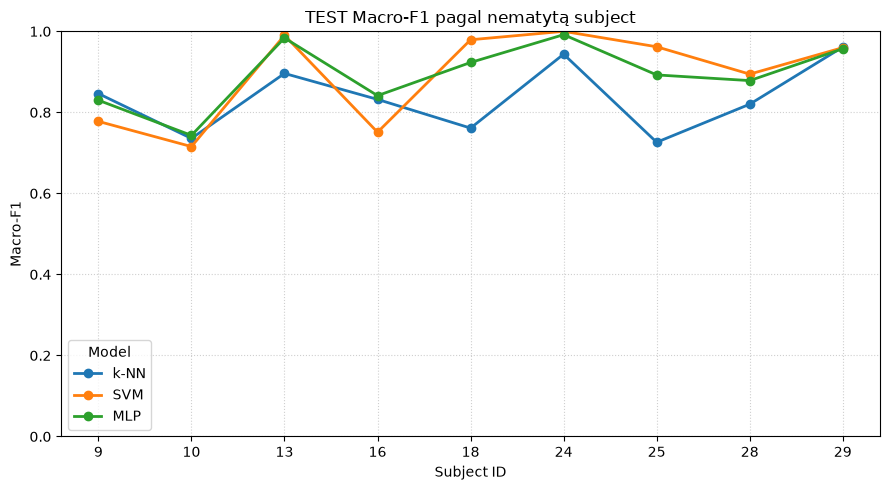

Išsaugota: per_subject_macro_f1.svg / .png


In [9]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))
x = np.arange(len(test_subjects))
for name in ["k-NN", "SVM", "MLP"]:
    sub = per_subject[per_subject["Model"] == name].set_index("Subject ID").loc[test_subjects]
    ax.plot(x, sub["Macro-F1"].to_numpy(), marker="o", linewidth=2, label=name)
ax.set_xticks(x, [str(s) for s in test_subjects])
ax.set_xlabel("Subject ID")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0.0, 1.0)
ax.set_title("TEST Macro-F1 pagal nematytą subject")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(title="Model")
fig.tight_layout()
fig.savefig(results_dir / "per_subject_macro_f1.svg", format="svg")
fig.savefig(results_dir / "per_subject_macro_f1.png", format="png", dpi=200)
plt.show()
print("Išsaugota: per_subject_macro_f1.svg / .png")

## Interpretacija

**Apribojimas.** Klaidingas pavyzdys čia yra TEST eilutė (561 požymiai), ne IMU grafikas.

**FAKTAI.** Kontrolinės TEST metrikos sutapo su 2/3 etapais. Klaidų skaičius: k-NN 491/3155, SVM 347/3155, MLP 340/3155.

Dažniausios nediagonalinės poros:
- k-NN: SITTING→STANDING 118, WALKING_DOWNSTAIRS→WALKING_UPSTAIRS 86, STANDING→SITTING 74;
- SVM: STANDING→SITTING 97, LAYING→STANDING 83, SITTING→STANDING 70;
- MLP: STANDING→SITTING 106, SITTING→STANDING 74, LAYING→STANDING 70.

Žemiausias klasės F1: k-NN SITTING (0.786); SVM STANDING (0.796); MLP STANDING (0.792). k-NN WALKING_DOWNSTAIRS recall yra 0.693 — žemiausias šio modelio recall.

Klaidų struktūra iš dalies sutampa (SITTING/STANDING visuose trijuose), bet skiriasi: k-NN turi didelę WALKING_DOWNSTAIRS→WALKING_UPSTAIRS porą (86), SVM — WALKING_UPSTAIRS→SITTING (59).

Visi 9 TEST subject turi 6 klases. Subject Macro-F1 diapazonas: k-NN 0.726–0.961, SVM 0.716–1.000, MLP 0.743–0.992. Rezultatai tarp nematytų žmonių skiriasi (pvz. SVM subject 24 = 1.000, subject 10 = 0.716).

Pavyzdžiai: k-NN TEST eilutė 6, subject 16, STANDING→SITTING; SVM ta pati eilutė 6, subject 16, STANDING→SITTING (decision true −0.625, predicted 0.618); MLP eilutė 0, subject 16, STANDING→SITTING.

**HIPOTEZĖ (neįrodyta).** Galimas paaiškinimas, kad SITTING ir STANDING statinių langų požymiai panašesni nei ėjimo veiklų, todėl riba tarp jų trapesnė. Šis notebook to mechanizmo neįrodo — matome tik painiojimo dažnius. Tai nėra galutinis modelio pasirinkimas.

## Išsaugojimas

Ankstesnių etapų CSV ir split neperrašomi.

In [10]:
per_class.to_csv(results_dir / "per_class_metrics.csv", index=False)
top_pairs.to_csv(results_dir / "top_confusion_pairs.csv", index=False)
misclassified.to_csv(results_dir / "misclassified_examples.csv", index=False)
per_subject.to_csv(results_dir / "per_subject_metrics.csv", index=False)
print("Išsaugota: per_class_metrics.csv, top_confusion_pairs.csv,")
print("misclassified_examples.csv, per_subject_metrics.csv")
print("Ankstesni rezultatų failai ir split nekeisti.")
if caught_warnings:
    print(pd.DataFrame(caught_warnings).drop_duplicates().to_string(index=False))
else:
    print("Warning nebuvo užfiksuota.")
print("6 etapas baigtas.")

Išsaugota: per_class_metrics.csv, top_confusion_pairs.csv,
misclassified_examples.csv, per_subject_metrics.csv
Ankstesni rezultatų failai ir split nekeisti.
Warning nebuvo užfiksuota.
6 etapas baigtas.
